<a href="https://colab.research.google.com/github/hirah-ma/scalable-rag-system/blob/main/similarity/EMBEDDINGS_pca_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 2 — Embeddings: Visualizing the Semantic Space with PCA

**Goal:** Embed 50 real sentences, compress 384 dimensions → 2D with PCA, and *see* how meaning clusters in space.  
**Stack:** `sentence-transformers` · `scikit-learn (PCA)` · `matplotlib` · `numpy`  
**Builds on:** Stage 1 (cosine similarity math)

---
## What you will discover
- High-dimensional vectors genuinely cluster by topic — this isn't magic, it's geometry
- PCA preserves the *most variance* in the data when squishing 384D → 2D
- Different embedding models produce different semantic spaces
- The distance between clusters in 2D predicts retrieval behavior in 384D

## Table of Contents
1. [Setup & Imports](#1)
2. [The Math: What PCA Actually Does](#2)
3. [Embed 50 Sentences (5 Topics)](#3)
4. [PCA: 384D → 2D](#4)
5. [Plot 1 — Basic Cluster Map](#5)
6. [Plot 2 — Annotated with Sentence Labels](#6)
7. [Plot 3 — PCA Variance Explained](#7)
8. [Plot 4 — Model Comparison (MiniLM vs MPNet)](#8)
9. [Plot 5 — Query Vector in Embedding Space](#9)
10. [Experiment: What Breaks the Clusters?](#10)
11. [Challenge Tasks](#11)

---
## 1. Setup & Imports <a id='1'></a>

In [1]:
!pip install sentence-transformers scikit-learn matplotlib numpy --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

np.random.seed(42)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
print("Imports ready.")

Imports ready.


   ---
## 2. The Math: What PCA Actually Does <a id='2'></a>

PCA (Principal Component Analysis) finds the directions of **maximum variance** in your data.

Given embeddings of shape `(50, 384)`:
1. **Center** the data: subtract the mean of each dimension → shape still `(50, 384)`
2. **Compute covariance matrix**: `C = (1/n) * X^T @ X` → shape `(384, 384)`
3. **Eigendecomposition**: find eigenvectors of C — these are the principal components
4. **Project**: `X_reduced = X @ PC[:, :2]` → shape `(50, 2)`

The first PC captures the most variance, the second captures the most of what remains.  
**Key insight:** if two sentences are close in 384D cosine space, they'll be close in 2D PCA space — not perfectly, but close enough to *see* the structure.

In [4]:
# Implement PCA manually to understand it — then verify against sklearn
def pca_manual(X, n_components=2):
    """
    Manual PCA implementation.
    X: shape (n_samples, n_features)
    Returns: reduced shape (n_samples, n_components), explained_variance_ratio
    """
    # Step 1: center
    X_centered = X - X.mean(axis=0)

    # Step 2: covariance matrix
    cov = np.cov(X_centered.T)                          # shape (n_features, n_features)

    # Step 3: eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)    # eigh = symmetric matrix

    # Step 4: sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Step 5: project onto top n_components
    components = eigenvectors[:, :n_components]
    X_reduced  = X_centered @ components

    explained_ratio = eigenvalues[:n_components] / eigenvalues.sum()
    return X_reduced, explained_ratio

# Quick test on toy data
toy = np.random.randn(20, 10)
reduced, ratios = pca_manual(toy, n_components=2)
print(f"Input shape:   {toy.shape}")
print(f"Output shape:  {reduced.shape}")
print(f"Variance explained by PC1: {ratios[0]:.3f}")
print(f"Variance explained by PC2: {ratios[1]:.3f}")
print(f"Combined:                  {ratios.sum():.3f}")

Input shape:   (20, 10)
Output shape:  (20, 2)
Variance explained by PC1: 0.216
Variance explained by PC2: 0.194
Combined:                  0.410


In [5]:
# Verify manual PCA matches sklearn
from sklearn.decomposition import PCA as SklearnPCA

sklearn_pca = SklearnPCA(n_components=2)
toy_sklearn  = sklearn_pca.fit_transform(toy)
toy_manual, _ = pca_manual(toy, n_components=2)

# Signs may flip — compare absolute values of coordinates
max_diff = np.max(np.abs(np.abs(toy_sklearn) - np.abs(toy_manual)))
print(f"Max coordinate difference (abs): {max_diff:.2e}")
print(f"Results match: {max_diff < 1e-8}")
print("\n(Sign flips are normal — eigenvectors have arbitrary sign direction)")

Max coordinate difference (abs): 1.24e-14
Results match: True

(Sign flips are normal — eigenvectors have arbitrary sign direction)


---
## 3. Embed 50 Sentences (5 Topics) <a id='3'></a>

10 sentences per topic. Topics chosen to have clear semantic separation.  
The 5 topics: **animals**, **machine learning**, **cooking**, **astronomy**, **healthcare**.

In [6]:
# 50 sentences across 5 topics — 10 each
corpus = {
    "animals": [
        "The golden retriever fetched the ball eagerly.",
        "A puppy wagged its tail in excitement.",
        "The cat stretched lazily in the afternoon sun.",
        "Elephants communicate using low-frequency rumbles.",
        "The eagle soared high above the mountain peaks.",
        "Dolphins are highly intelligent marine mammals.",
        "The wolf howled at the full moon.",
        "Penguins huddle together to survive Antarctic winters.",
        "A baby deer took its first wobbly steps.",
        "Chimpanzees use tools to extract termites from mounds.",
    ],
    "machine_learning": [
        "Gradient descent minimizes the loss function iteratively.",
        "Transformers use attention to weigh token importance.",
        "Overfitting occurs when a model memorizes training data.",
        "A learning rate too high causes training instability.",
        "Batch normalization stabilizes deep network training.",
        "Embeddings map discrete tokens to continuous vectors.",
        "Backpropagation computes gradients through the network.",
        "Regularization techniques reduce model complexity.",
        "Random forests combine many decision trees.",
        "Convolutional layers detect spatial patterns in images.",
    ],
    "cooking": [
        "Sauté the onions until they become translucent.",
        "Knead the dough for ten minutes until elastic.",
        "Deglaze the pan with white wine after browning.",
        "Season pasta water generously with salt.",
        "A mirepoix of onion, carrot, and celery forms the base.",
        "Tempering chocolate requires precise temperature control.",
        "Braising tough cuts of meat makes them tender.",
        "Emulsify butter into the sauce off the heat.",
        "Blanch vegetables in boiling water then shock in ice.",
        "Rest the steak for five minutes before slicing.",
    ],
    "astronomy": [
        "Black holes bend spacetime with extreme gravitational force.",
        "The Milky Way contains over 200 billion stars.",
        "Neutron stars are the densest objects in the universe.",
        "Light from the sun takes eight minutes to reach Earth.",
        "Dark matter makes up most of the universe's mass.",
        "Supernovae forge heavy elements and scatter them across space.",
        "Exoplanets orbit stars beyond our solar system.",
        "The cosmic microwave background is an echo of the Big Bang.",
        "Pulsars emit regular radio pulses like cosmic lighthouses.",
        "Jupiter's Great Red Spot is a centuries-old storm system.",
    ],
    "healthcare": [
        "Hypertension increases the risk of cardiovascular disease.",
        "mRNA vaccines train the immune system without live virus.",
        "Insulin regulates blood glucose in diabetic patients.",
        "Antibiotics are ineffective against viral infections.",
        "MRI scans use magnetic fields to image soft tissue.",
        "Statins lower LDL cholesterol levels in the bloodstream.",
        "Cognitive behavioral therapy treats anxiety and depression.",
        "Sepsis is a life-threatening response to infection.",
        "Stem cells can differentiate into specialized tissue types.",
        "Chemotherapy targets rapidly dividing cancer cells.",
    ],
}

# Flatten with labels
sentences, topic_labels, topic_ids = [], [], []
topic_list = list(corpus.keys())
color_map  = {
    "animals":         "#1D9E75",
    "machine_learning":"#534AB7",
    "cooking":         "#D85A30",
    "astronomy":       "#185FA5",
    "healthcare":      "#A32D2D",
}

for tid, (topic, sents) in enumerate(corpus.items()):
    for s in sents:
        sentences.append(s)
        topic_labels.append(topic)
        topic_ids.append(tid)

topic_labels_arr = np.array(topic_labels)
topic_ids_arr    = np.array(topic_ids)

print(f"Total sentences: {len(sentences)}")
print(f"Topics: {topic_list}")
print(f"Sentences per topic: {len(sentences) // len(topic_list)}")

Total sentences: 50
Topics: ['animals', 'machine_learning', 'cooking', 'astronomy', 'healthcare']
Sentences per topic: 10


In [7]:
# Load model and embed
print("Loading all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Embedding {len(sentences)} sentences ...")
embeddings = model.encode(sentences, show_progress_bar=True, normalize_embeddings=True)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Each sentence -> {embeddings.shape[1]}-dimensional unit vector")
print(f"(normalize_embeddings=True means cosine similarity = dot product)")

Loading all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 50 sentences ...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embeddings shape: (50, 384)
Each sentence -> 384-dimensional unit vector
(normalize_embeddings=True means cosine similarity = dot product)


---
## 4. PCA: 384D → 2D <a id='4'></a>

In [8]:
# Fit PCA
pca = PCA(n_components=50, random_state=42)   # keep 50 components first to analyze variance
pca.fit(embeddings)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
dims_for_90pct = np.searchsorted(cumulative_variance, 0.90) + 1
dims_for_95pct = np.searchsorted(cumulative_variance, 0.95) + 1

print(f"Dimensions needed to explain 90% of variance: {dims_for_90pct}")
print(f"Dimensions needed to explain 95% of variance: {dims_for_95pct}")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"PC1+PC2 combined: {cumulative_variance[1]*100:.1f}%")
print()
print("This means a 2D plot captures only ~X% of the total structure.")
print("Points that look close in 2D may still be far apart in 384D.")
print("But clusters that are clearly separated in 2D are genuinely separated in 384D.")

Dimensions needed to explain 90% of variance: 36
Dimensions needed to explain 95% of variance: 42
PC1 explains: 0.074 (7.4%)
PC2 explains: 0.069 (6.9%)
PC1+PC2 combined: 14.3%

This means a 2D plot captures only ~X% of the total structure.
Points that look close in 2D may still be far apart in 384D.
But clusters that are clearly separated in 2D are genuinely separated in 384D.


In [9]:
# Project to 2D
pca2 = PCA(n_components=2, random_state=42)
coords_2d = pca2.fit_transform(embeddings)    # shape (50, 2)

print(f"2D coordinates shape: {coords_2d.shape}")
print(f"X range: [{coords_2d[:,0].min():.3f}, {coords_2d[:,0].max():.3f}]")
print(f"Y range: [{coords_2d[:,1].min():.3f}, {coords_2d[:,1].max():.3f}]")

2D coordinates shape: (50, 2)
X range: [-0.348, 0.568]
Y range: [-0.398, 0.547]


---
## 5. Plot 1 — Basic Cluster Map <a id='5'></a>

This is the core visualization. Each dot = one sentence. Color = topic.  
If the embedding model understands meaning, same-topic dots cluster together.

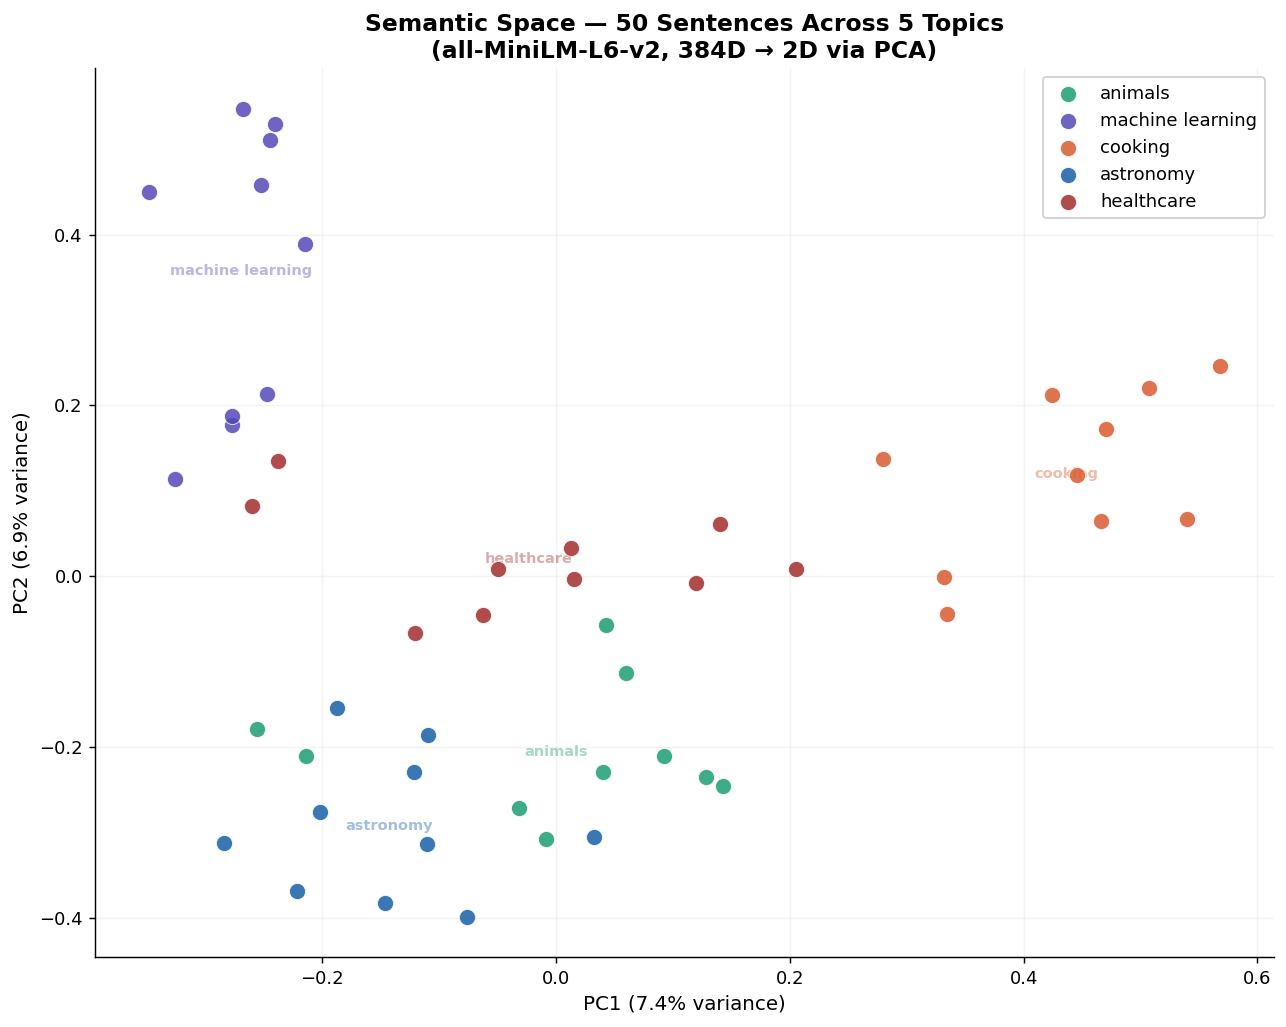

Saved: stage2_01_cluster_map.png

What to look for:
  - Same-color dots should cluster together
  - Topics that are conceptually related should be closer (e.g. ML + healthcare?)
  - Outlier dots within a cluster: sentences that mention multiple topics


In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

for topic in topic_list:
    mask = topic_labels_arr == topic
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=color_map[topic], s=80, alpha=0.85,
        label=topic.replace('_', ' '), edgecolors='white', linewidths=0.5, zorder=3
    )

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title("Semantic Space — 50 Sentences Across 5 Topics\n(all-MiniLM-L6-v2, 384D → 2D via PCA)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9, loc='best')
ax.grid(True, alpha=0.15, zorder=0)

# Annotate cluster centers
for topic in topic_list:
    mask = topic_labels_arr == topic
    cx = coords_2d[mask, 0].mean()
    cy = coords_2d[mask, 1].mean()
    ax.text(cx, cy, topic.replace('_', ' ' ), fontsize=8, ha='center', va='center',
            color=color_map[topic], fontweight='bold', alpha=0.4, zorder=2)

plt.tight_layout()
plt.savefig('stage2_01_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_01_cluster_map.png")
print()
print("What to look for:")
print("  - Same-color dots should cluster together")
print("  - Topics that are conceptually related should be closer (e.g. ML + healthcare?)")
print("  - Outlier dots within a cluster: sentences that mention multiple topics")

---
## 6. Plot 2 — Annotated with Sentence Labels <a id='6'></a>

Same plot, but with actual text. This reveals *which sentences* are outliers within their cluster.

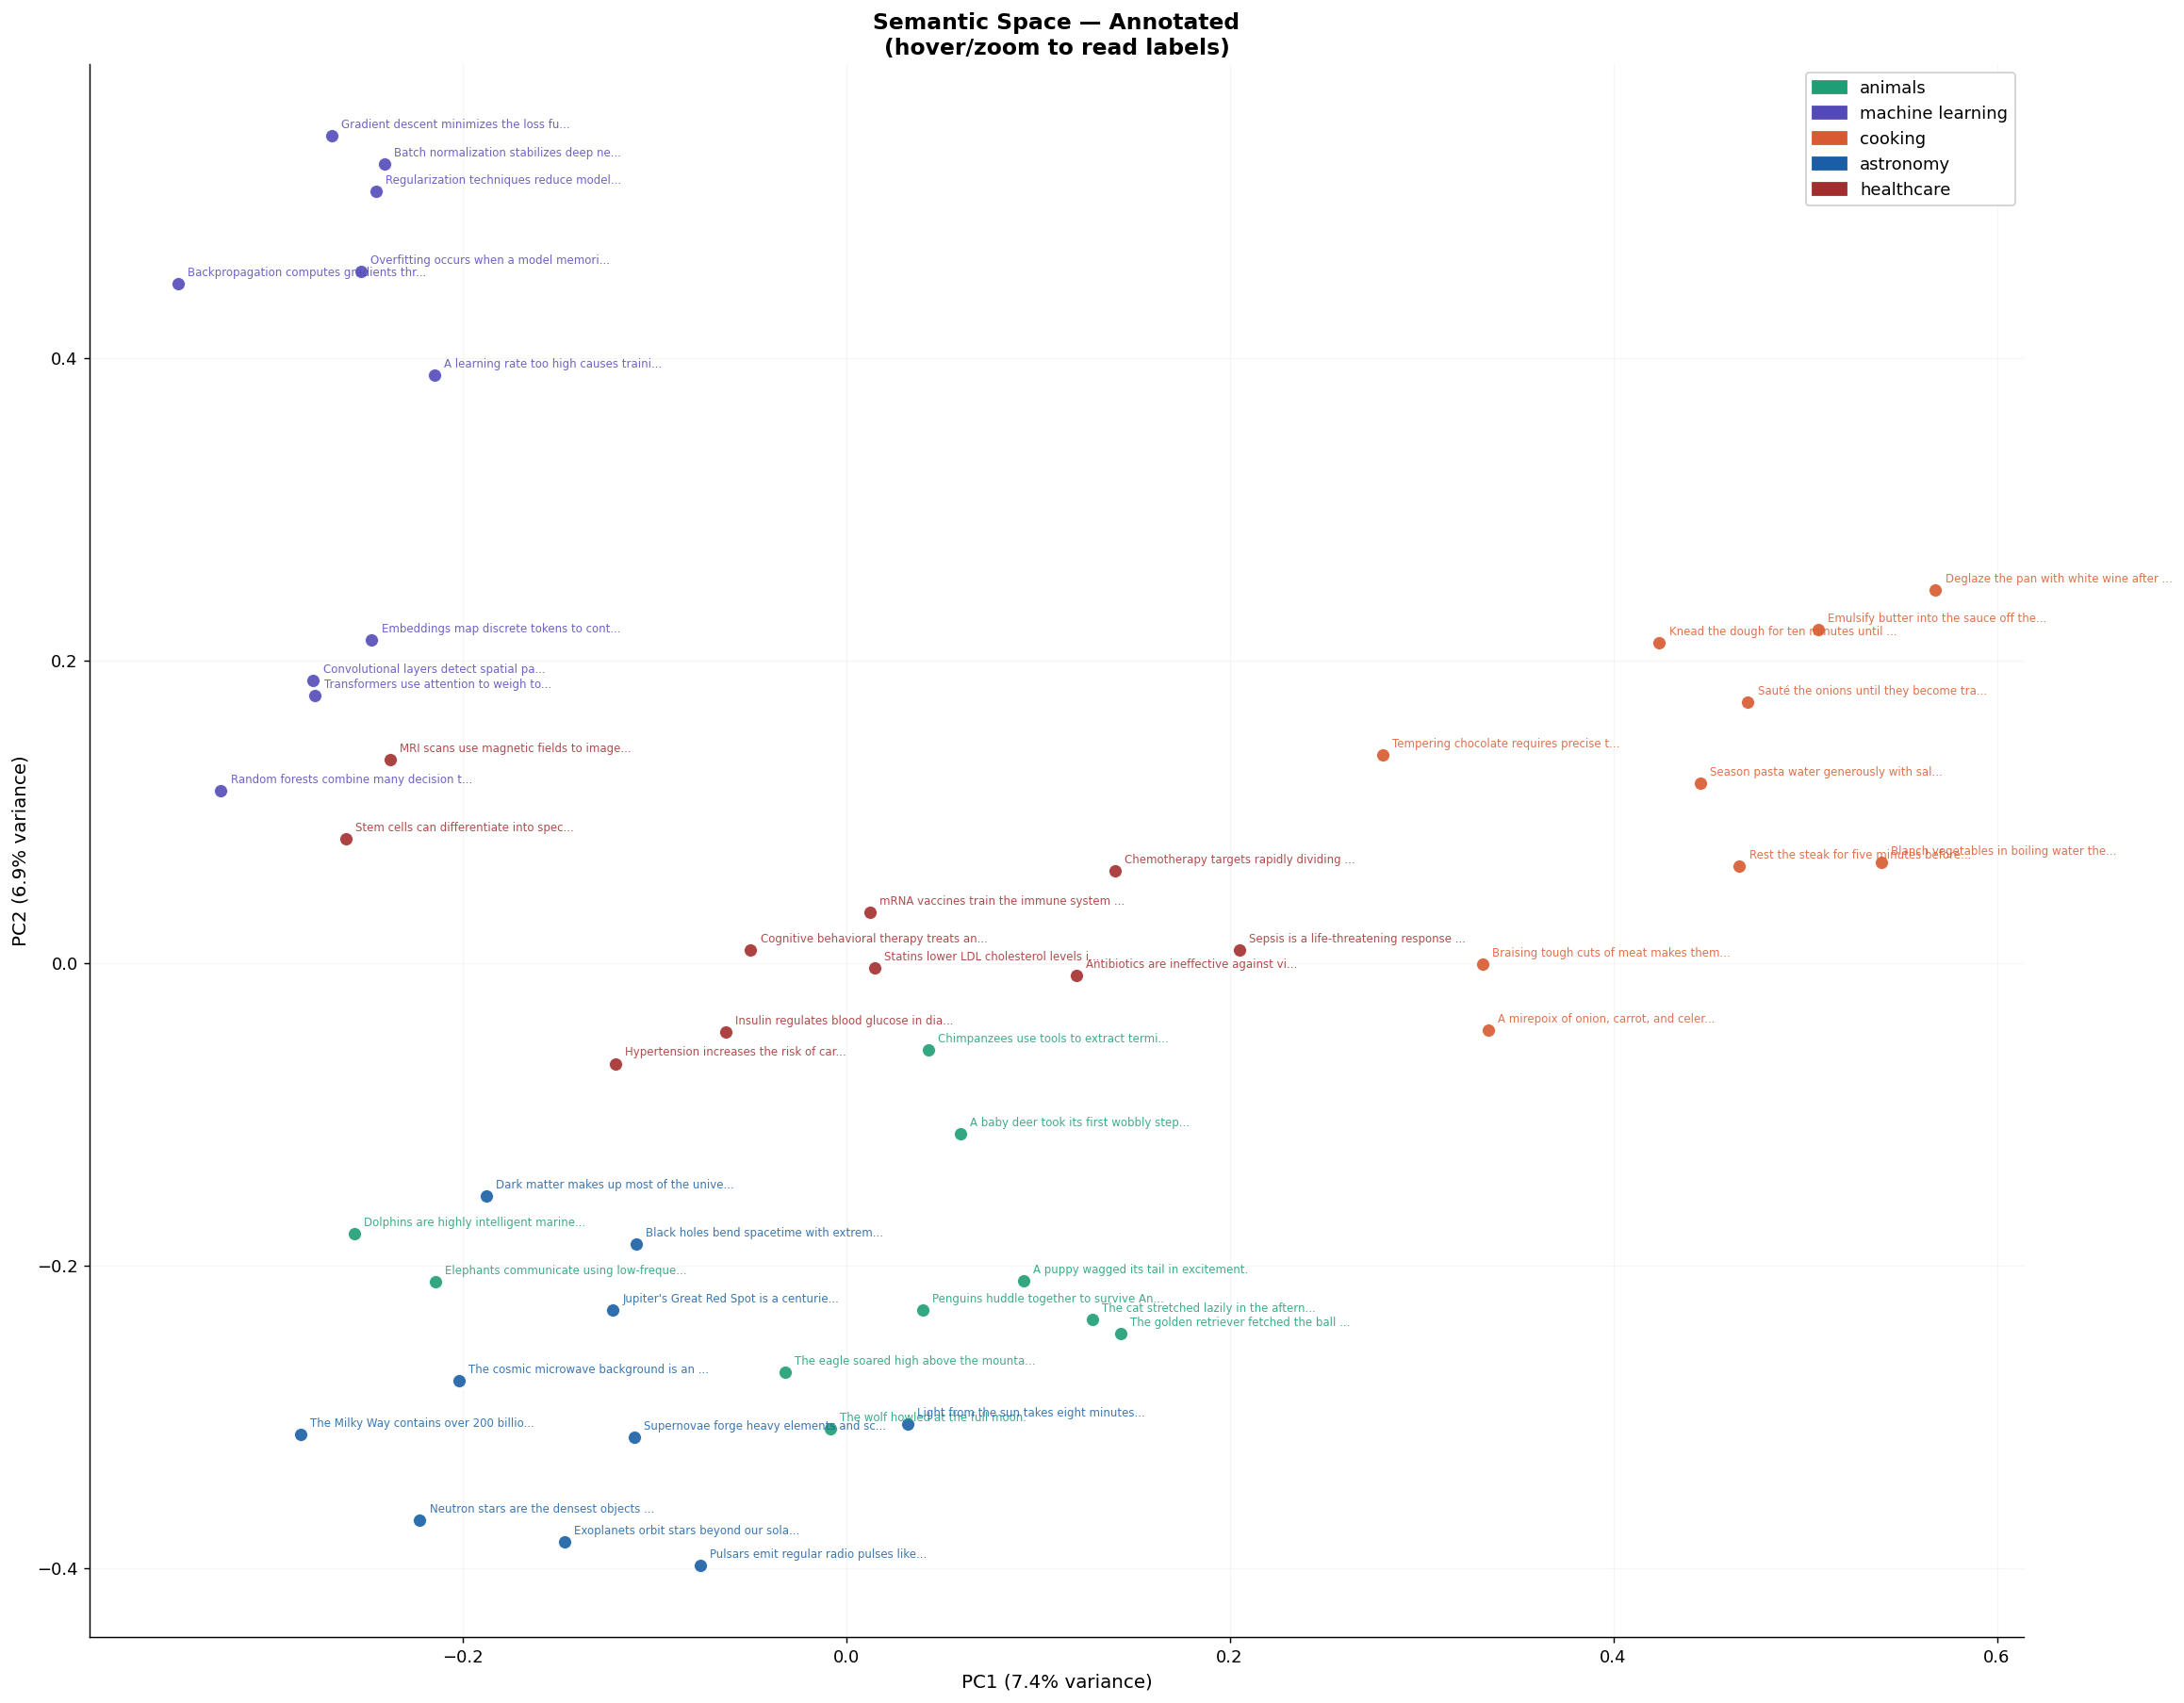

Saved: stage2_02_annotated.png

Find the interesting sentences:
  - Which sentence is farthest from its own cluster?
  - Which two sentences from DIFFERENT topics ended up closest together?


In [12]:
fig, ax = plt.subplots(figsize=(18, 14))

for topic in topic_list:
    mask = topic_labels_arr == topic
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=color_map[topic], s=60, alpha=0.9,
        edgecolors='white', linewidths=0.5, zorder=3
    )

# Add text labels
for i, (x, y, sentence, topic) in enumerate(zip(
        coords_2d[:, 0], coords_2d[:, 1], sentences, topic_labels)):
    short = sentence[:38] + "..." if len(sentence) > 38 else sentence
    ax.text(x + 0.005, y + 0.005, short,
            fontsize=6.5, color=color_map[topic], alpha=0.85, zorder=4)

legend_patches = [mpatches.Patch(color=color_map[t], label=t.replace('_', ' '))
                  for t in topic_list]
ax.legend(handles=legend_patches, fontsize=10, loc='best', framealpha=0.9)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title("Semantic Space — Annotated\n(hover/zoom to read labels)",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.1, zorder=0)

plt.tight_layout()
plt.savefig('stage2_02_annotated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_02_annotated.png")
print()
print("Find the interesting sentences:")
print("  - Which sentence is farthest from its own cluster?")
print("  - Which two sentences from DIFFERENT topics ended up closest together?")

In [13]:
# Find and print the cross-topic nearest neighbor pairs
print("Cross-topic nearest neighbor pairs (sentences from different topics that are most similar):\n")
sim_matrix = cosine_similarity(embeddings)

cross_pairs = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        if topic_labels[i] != topic_labels[j]:
            cross_pairs.append((sim_matrix[i][j], i, j))

cross_pairs.sort(reverse=True)

print(f"{'Similarity':>10}  Pair")
for score, i, j in cross_pairs[:8]:
    print(f"  {score:.4f}  [{topic_labels[i][:8]:>8}] {sentences[i][:50]}")
    print(f"           [{topic_labels[j][:8]:>8}] {sentences[j][:50]}")
    print()

Cross-topic nearest neighbor pairs (sentences from different topics that are most similar):

Similarity  Pair
  0.3138  [ animals] The cat stretched lazily in the afternoon sun.
           [astronom] Light from the sun takes eight minutes to reach Ea

  0.2550  [ cooking] Rest the steak for five minutes before slicing.
           [astronom] Light from the sun takes eight minutes to reach Ea

  0.2513  [machine_] Convolutional layers detect spatial patterns in im
           [healthca] MRI scans use magnetic fields to image soft tissue

  0.2459  [ animals] Elephants communicate using low-frequency rumbles.
           [astronom] Pulsars emit regular radio pulses like cosmic ligh

  0.2377  [ animals] The golden retriever fetched the ball eagerly.
           [astronom] Light from the sun takes eight minutes to reach Ea

  0.2235  [ animals] Chimpanzees use tools to extract termites from mou
           [ cooking] A mirepoix of onion, carrot, and celery forms the 

  0.2145  [machine_] Batc

---
## 7. Plot 3 — PCA Variance Explained <a id='7'></a>

This answers: "How much information are we losing by going to 2D?"  
The scree plot shows the elbow — where adding more components stops helping much.

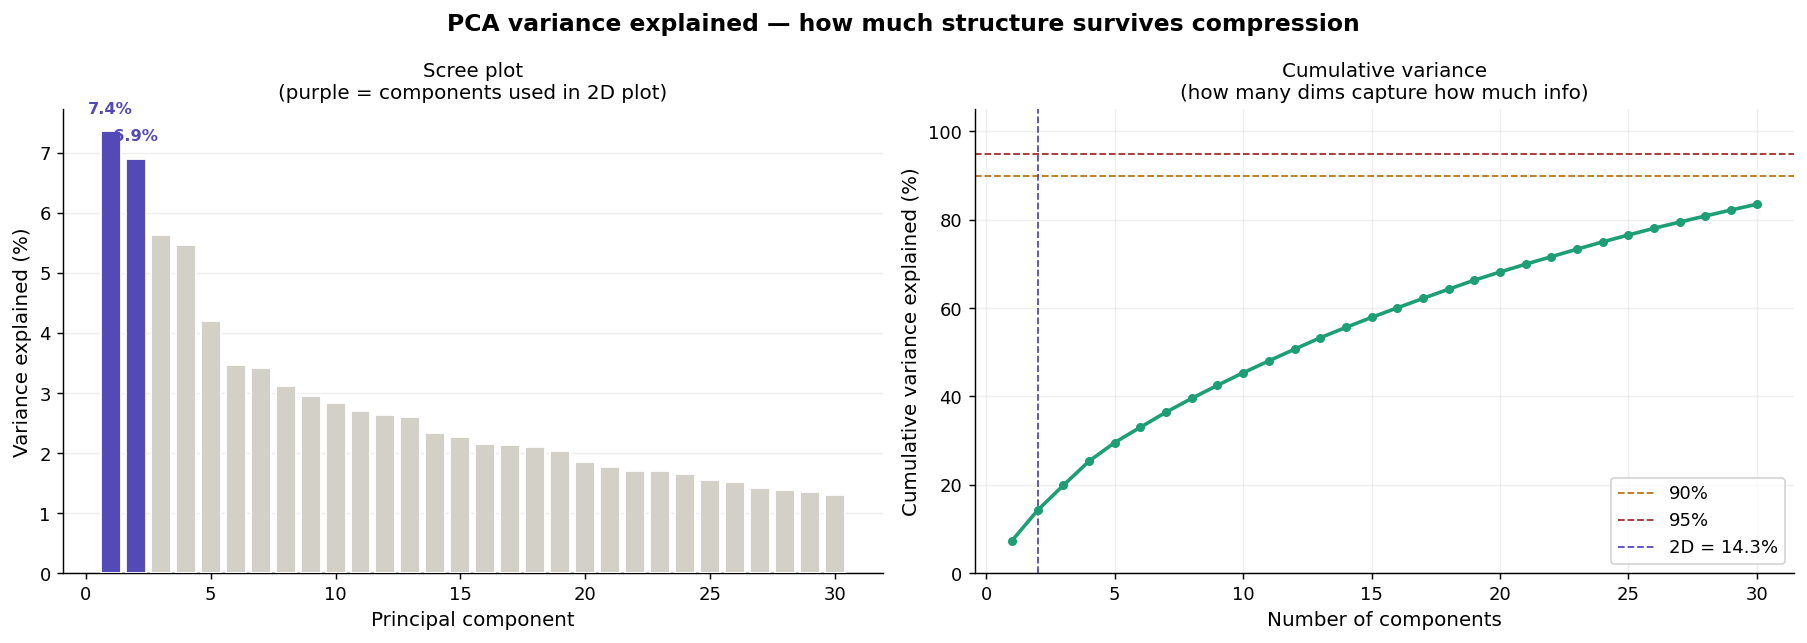

Saved: stage2_03_variance_explained.png

The 2D plot captures 14.3% of total variance.
That means 85.7% of structure is invisible in the plot.
This is why 2D PCA is for intuition, not for measuring exact distances.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA variance explained — how much structure survives compression",
             fontsize=13, fontweight='bold')

n_show = 30
ratios = pca.explained_variance_ratio_[:n_show]
cumulative = np.cumsum(pca.explained_variance_ratio_)[:n_show]

# Left: per-component bar chart (scree plot)
ax = axes[0]
bar_colors = ['#534AB7' if i < 2 else '#D3D1C7' for i in range(n_show)]
ax.bar(range(1, n_show+1), ratios * 100, color=bar_colors, edgecolor='white', zorder=3)
ax.set_xlabel("Principal component", fontsize=11)
ax.set_ylabel("Variance explained (%)", fontsize=11)
ax.set_title("Scree plot\n(purple = components used in 2D plot)", fontsize=11)
ax.grid(axis='y', alpha=0.2, zorder=0)

ax.text(1, ratios[0]*100 + 0.3, f"{ratios[0]*100:.1f}%",
        ha='center', fontsize=9, color='#534AB7', fontweight='bold')
ax.text(2, ratios[1]*100 + 0.3, f"{ratios[1]*100:.1f}%",
        ha='center', fontsize=9, color='#534AB7', fontweight='bold')

# Right: cumulative
ax = axes[1]
ax.plot(range(1, n_show+1), cumulative * 100,
        color='#1D9E75', linewidth=2, marker='o', markersize=4, zorder=3)
ax.axhline(y=90, color='#BA7517', linestyle='--', linewidth=1, label='90%', zorder=2)
ax.axhline(y=95, color='#A32D2D', linestyle='--', linewidth=1, label='95%', zorder=2)
ax.axvline(x=2,  color='#534AB7', linestyle='--', linewidth=1,
           label=f'2D = {cumulative[1]*100:.1f}%', zorder=2)
ax.set_xlabel("Number of components", fontsize=11)
ax.set_ylabel("Cumulative variance explained (%)", fontsize=11)
ax.set_title("Cumulative variance\n(how many dims capture how much info)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.2, zorder=0)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('stage2_03_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_03_variance_explained.png")
print()
print(f"The 2D plot captures {cumulative[1]*100:.1f}% of total variance.")
print(f"That means {100 - cumulative[1]*100:.1f}% of structure is invisible in the plot.")
print("This is why 2D PCA is for intuition, not for measuring exact distances.")

---
## 8. Plot 4 — Model Comparison: MiniLM vs MPNet <a id='8'></a>

Different models produce different semantic spaces.  
`all-MiniLM-L6-v2` is fast (22M params). `all-mpnet-base-v2` is better quality (110M params).  
How different do their 2D projections look on the same 50 sentences?

In [15]:
print("Loading all-mpnet-base-v2 (110M params, slower but better quality)...")
model_mpnet = SentenceTransformer('all-mpnet-base-v2')
embeddings_mpnet = model_mpnet.encode(sentences, show_progress_bar=True, normalize_embeddings=True)
print(f"MPNet embeddings shape: {embeddings_mpnet.shape}")

Loading all-mpnet-base-v2 (110M params, slower but better quality)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

MPNet embeddings shape: (50, 768)


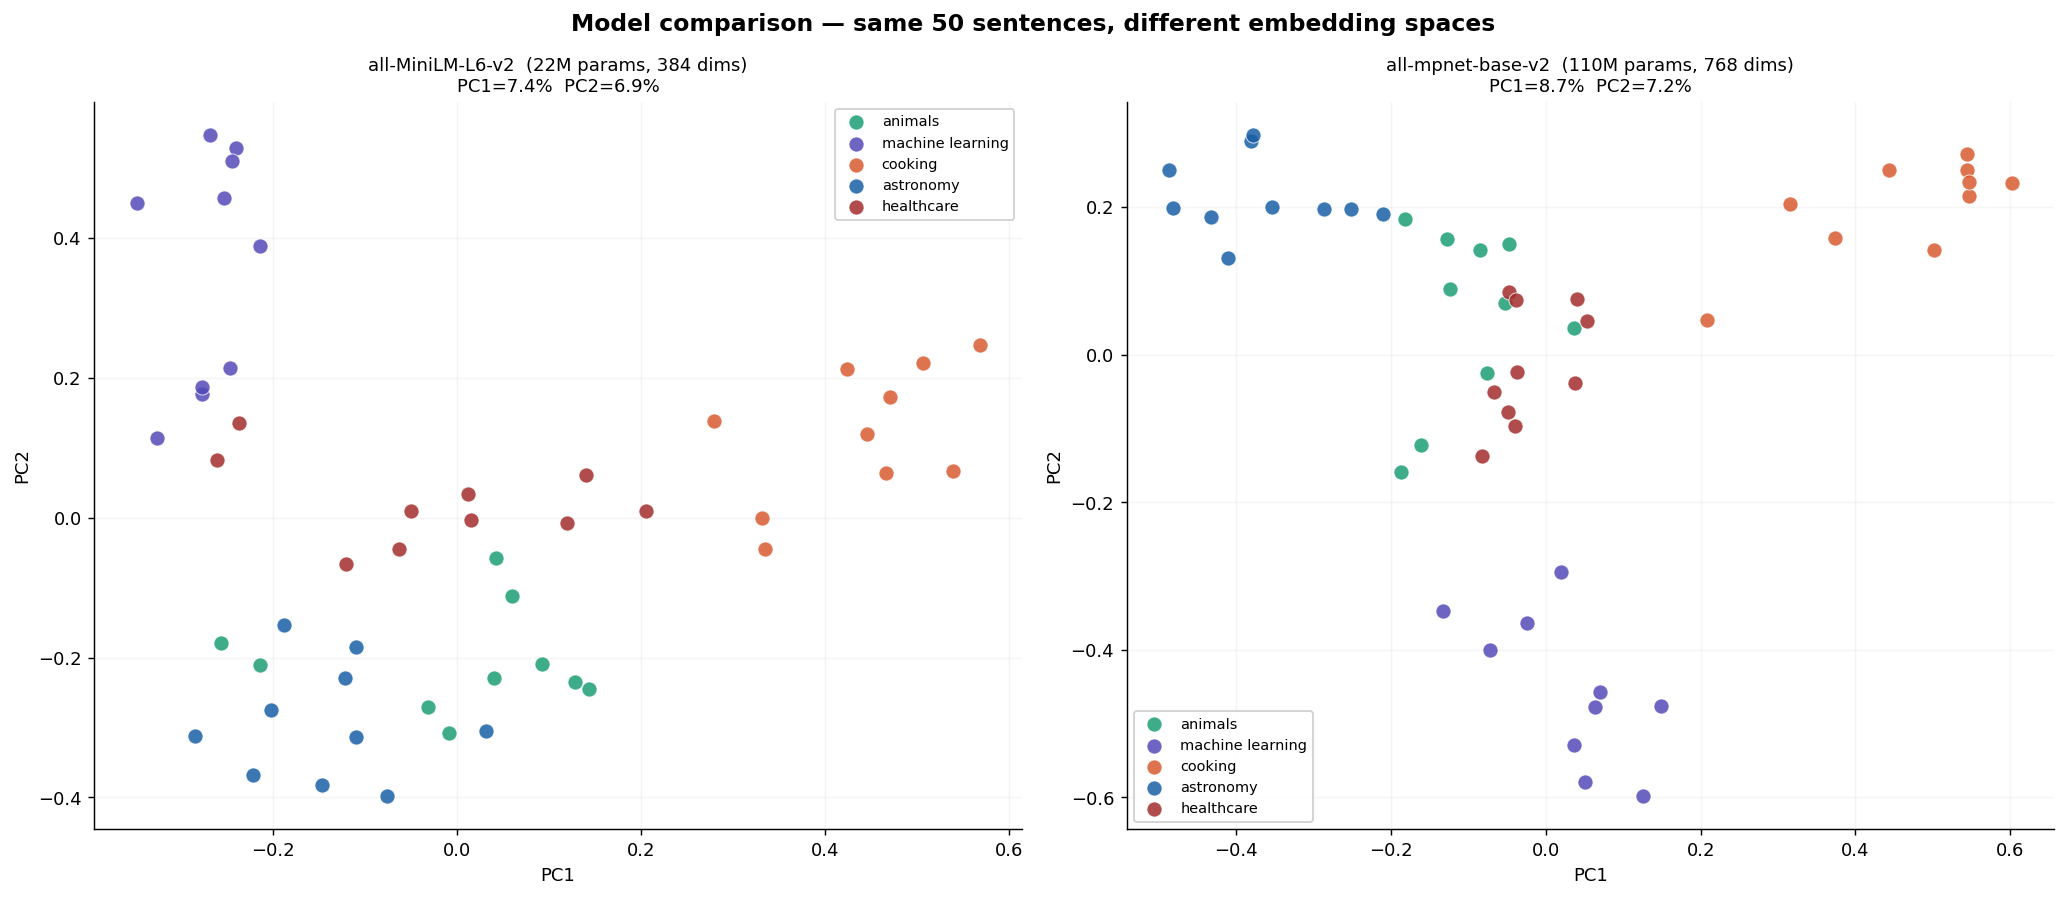

Saved: stage2_04_model_comparison.png

Questions to answer after looking at both plots:
  1. Which model produces tighter clusters?
  2. Does the relative position of topics change between models?
  3. Which model would you use for a production RAG system and why?


In [16]:
# PCA on both
pca_mpnet = PCA(n_components=2, random_state=42)
coords_mpnet = pca_mpnet.fit_transform(embeddings_mpnet)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Model comparison — same 50 sentences, different embedding spaces",
             fontsize=13, fontweight='bold')

for ax, coords, title, var in [
    (axes[0], coords_2d,    "all-MiniLM-L6-v2  (22M params, 384 dims)",
     pca2.explained_variance_ratio_),
    (axes[1], coords_mpnet, "all-mpnet-base-v2  (110M params, 768 dims)",
     pca_mpnet.explained_variance_ratio_),
]:
    for topic in topic_list:
        mask = topic_labels_arr == topic
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=color_map[topic], s=70, alpha=0.85,
            label=topic.replace('_', ' '), edgecolors='white', linewidths=0.5, zorder=3
        )
    ax.set_title(f"{title}\nPC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%", fontsize=10)
    ax.set_xlabel("PC1", fontsize=10); ax.set_ylabel("PC2", fontsize=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.12, zorder=0)

plt.tight_layout()
plt.savefig('stage2_04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_04_model_comparison.png")
print()
print("Questions to answer after looking at both plots:")
print("  1. Which model produces tighter clusters?")
print("  2. Does the relative position of topics change between models?")
print("  3. Which model would you use for a production RAG system and why?")

In [17]:
# Quantify cluster quality with intra vs inter cluster cosine similarity
def cluster_quality(embeddings, labels):
    """
    Returns intra-cluster avg similarity and inter-cluster avg similarity.
    Good clusters have high intra, low inter.
    """
    sim = cosine_similarity(embeddings)
    topics = list(set(labels))
    intra_scores, inter_scores = [], []

    for t in topics:
        mask = np.array(labels) == t
        idxs = np.where(mask)[0]
        not_idxs = np.where(~mask)[0]
        # intra
        for i in idxs:
            for j in idxs:
                if i < j:
                    intra_scores.append(sim[i][j])
        # inter
        for i in idxs:
            for j in not_idxs:
                inter_scores.append(sim[i][j])

    return np.mean(intra_scores), np.mean(inter_scores)

intra_mini, inter_mini   = cluster_quality(embeddings, topic_labels)
intra_mpnet, inter_mpnet = cluster_quality(embeddings_mpnet, topic_labels)

print(f"{'Model':<30} {'Intra-cluster sim':>18} {'Inter-cluster sim':>18} {'Separation':>12}")
print("-" * 80)
print(f"{'MiniLM-L6-v2':<30} {intra_mini:>18.4f} {inter_mini:>18.4f} {intra_mini-inter_mini:>12.4f}")
print(f"{'MPNet-base-v2':<30} {intra_mpnet:>18.4f} {inter_mpnet:>18.4f} {intra_mpnet-inter_mpnet:>12.4f}")
print()
print("Higher intra, lower inter = better model for this domain.")
print("Separation = intra - inter. Higher is better.")

Model                           Intra-cluster sim  Inter-cluster sim   Separation
--------------------------------------------------------------------------------
MiniLM-L6-v2                               0.2057             0.0268       0.1789
MPNet-base-v2                              0.2309             0.0312       0.1997

Higher intra, lower inter = better model for this domain.
Separation = intra - inter. Higher is better.


---
## 9. Plot 5 — Query Vector in Embedding Space <a id='9'></a>

See exactly where a query lands in the 2D semantic map.  
This is what a RAG retriever 'sees' when it searches — the query projected into the same space.

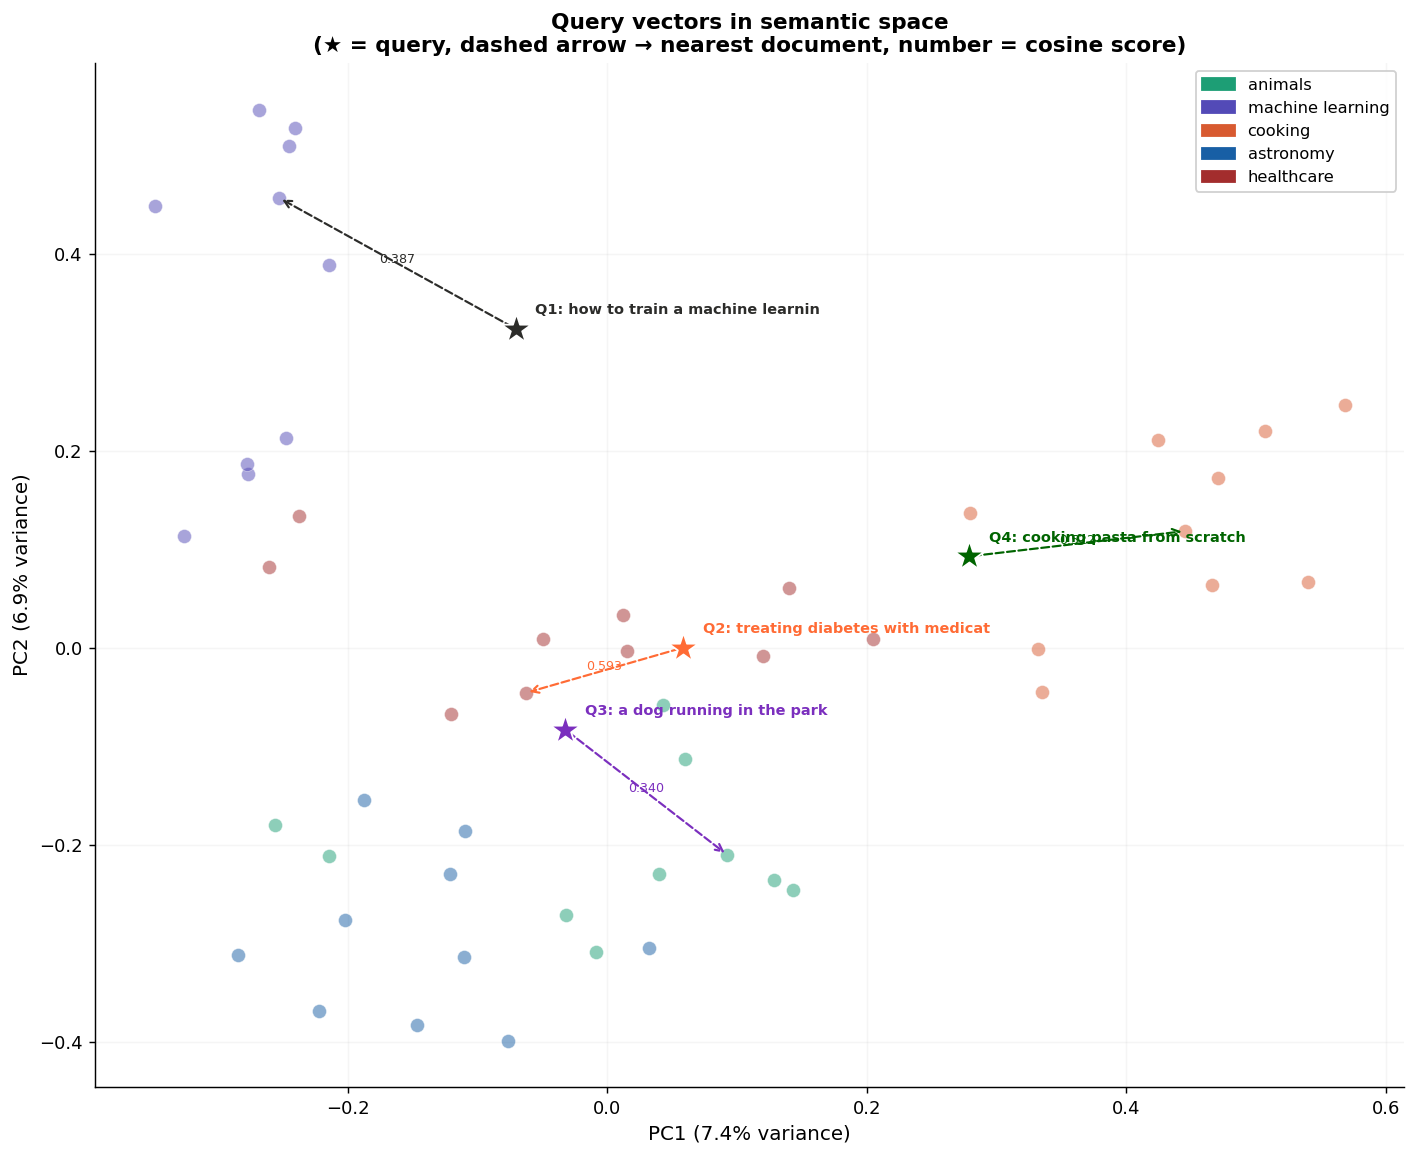

Saved: stage2_05_query_in_space.png


In [18]:
queries = [
    "how to train a machine learning model",
    "treating diabetes with medication",
    "a dog running in the park",
    "cooking pasta from scratch",
]

# Embed queries using the same model + PCA projection
# IMPORTANT: use pca2.transform (not fit_transform) — project onto existing axes
q_embeddings = model.encode(queries, normalize_embeddings=True)
q_coords_2d  = pca2.transform(q_embeddings)   # shape (4, 2)

fig, ax = plt.subplots(figsize=(11, 9))

# Background corpus points
for topic in topic_list:
    mask = topic_labels_arr == topic
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=color_map[topic], s=60, alpha=0.5,
        edgecolors='white', linewidths=0.4, zorder=2
    )

# Query points — big stars
query_colors = ['#2C2C2A', '#FF6B35', '#7B2FBE', '#006400']
for i, (qc, qlabel) in enumerate(zip(q_coords_2d, queries)):
    ax.scatter(qc[0], qc[1], c=query_colors[i], s=300, marker='*',
               zorder=5, edgecolors='white', linewidths=1)
    ax.text(qc[0] + 0.015, qc[1] + 0.015,
            f'Q{i+1}: {qlabel[:30]}', fontsize=8,
            color=query_colors[i], fontweight='bold', zorder=6)

    # Draw arrow to nearest corpus neighbor
    q_vec = q_embeddings[i]
    sims  = cosine_similarity([q_vec], embeddings)[0]
    nearest = np.argmax(sims)
    ax.annotate('', xy=coords_2d[nearest], xytext=qc,
                arrowprops=dict(arrowstyle='->', color=query_colors[i],
                                lw=1.2, linestyle='dashed'))
    ax.text((qc[0] + coords_2d[nearest, 0])/2,
            (qc[1] + coords_2d[nearest, 1])/2,
            f"{sims[nearest]:.3f}", fontsize=7,
            color=query_colors[i], ha='center', zorder=6)

legend_patches  = [mpatches.Patch(color=color_map[t], label=t.replace('_', ' '))
                   for t in topic_list]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.9)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title("Query vectors in semantic space\n(★ = query, dashed arrow → nearest document, number = cosine score)",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.12, zorder=0)

plt.tight_layout()
plt.savefig('stage2_05_query_in_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_05_query_in_space.png")

In [19]:
# Print full retrieval results for each query
print("Top-3 retrieval results for each query:\n")
for i, query in enumerate(queries):
    q_vec = q_embeddings[i]
    sims  = cosine_similarity([q_vec], embeddings)[0]
    top3  = np.argsort(sims)[::-1][:3]
    print(f"Query: '{query}'")
    for rank, idx in enumerate(top3, 1):
        print(f"  #{rank} [{sims[idx]:.4f}] ({topic_labels[idx]}) {sentences[idx]}")
    print()

Top-3 retrieval results for each query:

Query: 'how to train a machine learning model'
  #1 [0.3871] (machine_learning) Overfitting occurs when a model memorizes training data.
  #2 [0.2997] (machine_learning) Regularization techniques reduce model complexity.
  #3 [0.2770] (machine_learning) Backpropagation computes gradients through the network.

Query: 'treating diabetes with medication'
  #1 [0.5934] (healthcare) Insulin regulates blood glucose in diabetic patients.
  #2 [0.2951] (healthcare) Antibiotics are ineffective against viral infections.
  #3 [0.1892] (healthcare) Statins lower LDL cholesterol levels in the bloodstream.

Query: 'a dog running in the park'
  #1 [0.3400] (animals) A puppy wagged its tail in excitement.
  #2 [0.3219] (animals) The golden retriever fetched the ball eagerly.
  #3 [0.2027] (animals) The cat stretched lazily in the afternoon sun.

Query: 'cooking pasta from scratch'
  #1 [0.5216] (cooking) Season pasta water generously with salt.
  #2 [0.2588] (c

---
## 10. Experiment: What Breaks the Clusters? <a id='10'></a>

Two adversarial experiments that reveal the limits of embedding models.

In [22]:
# Experiment A: ambiguous sentences that could belong to multiple topics
ambiguous = [
    "The network showed signs of infection.",          # healthcare? or computers?
    "We trained the model on healthy patient data.",   # ML + healthcare
    "The stars performed brilliantly last night.",     # astronomy? or entertainment?
    "Cook the data before serving it to the model.",   # cooking + ML
]

amb_embeddings = model.encode(ambiguous, normalize_embeddings=True)
amb_coords_2d  = pca2.transform(amb_embeddings)

# Predict which cluster they land in
sims_to_corpus = cosine_similarity(amb_embeddings, embeddings)

print("Ambiguous sentence analysis:")
print(f"{'Sentence':<50} {'Predicted topic':<20} {'Score':<8}")
print("-" * 82)
for i, sent in enumerate(ambiguous):
    nearest_doc   = np.argmax(sims_to_corpus[i])
    nearest_topic = topic_labels[nearest_doc]
    score         = sims_to_corpus[i][nearest_doc]
    print(f"{sent[:50]:<50} {nearest_topic:<20} {score:.4f}")

print()
print("Do the predictions match your intuition?")
print("This is a real failure mode in RAG: a query about 'network infection'")
print("might retrieve networking docs instead of healthcare docs.")

Ambiguous sentence analysis:
Sentence                                           Predicted topic      Score   
----------------------------------------------------------------------------------
The network showed signs of infection.             healthcare           0.3229
We trained the model on healthy patient data.      machine_learning     0.3671
The stars performed brilliantly last night.        astronomy            0.3767
Cook the data before serving it to the model.      cooking              0.3366

Do the predictions match your intuition?
This is a real failure mode in RAG: a query about 'network infection'
might retrieve networking docs instead of healthcare docs.


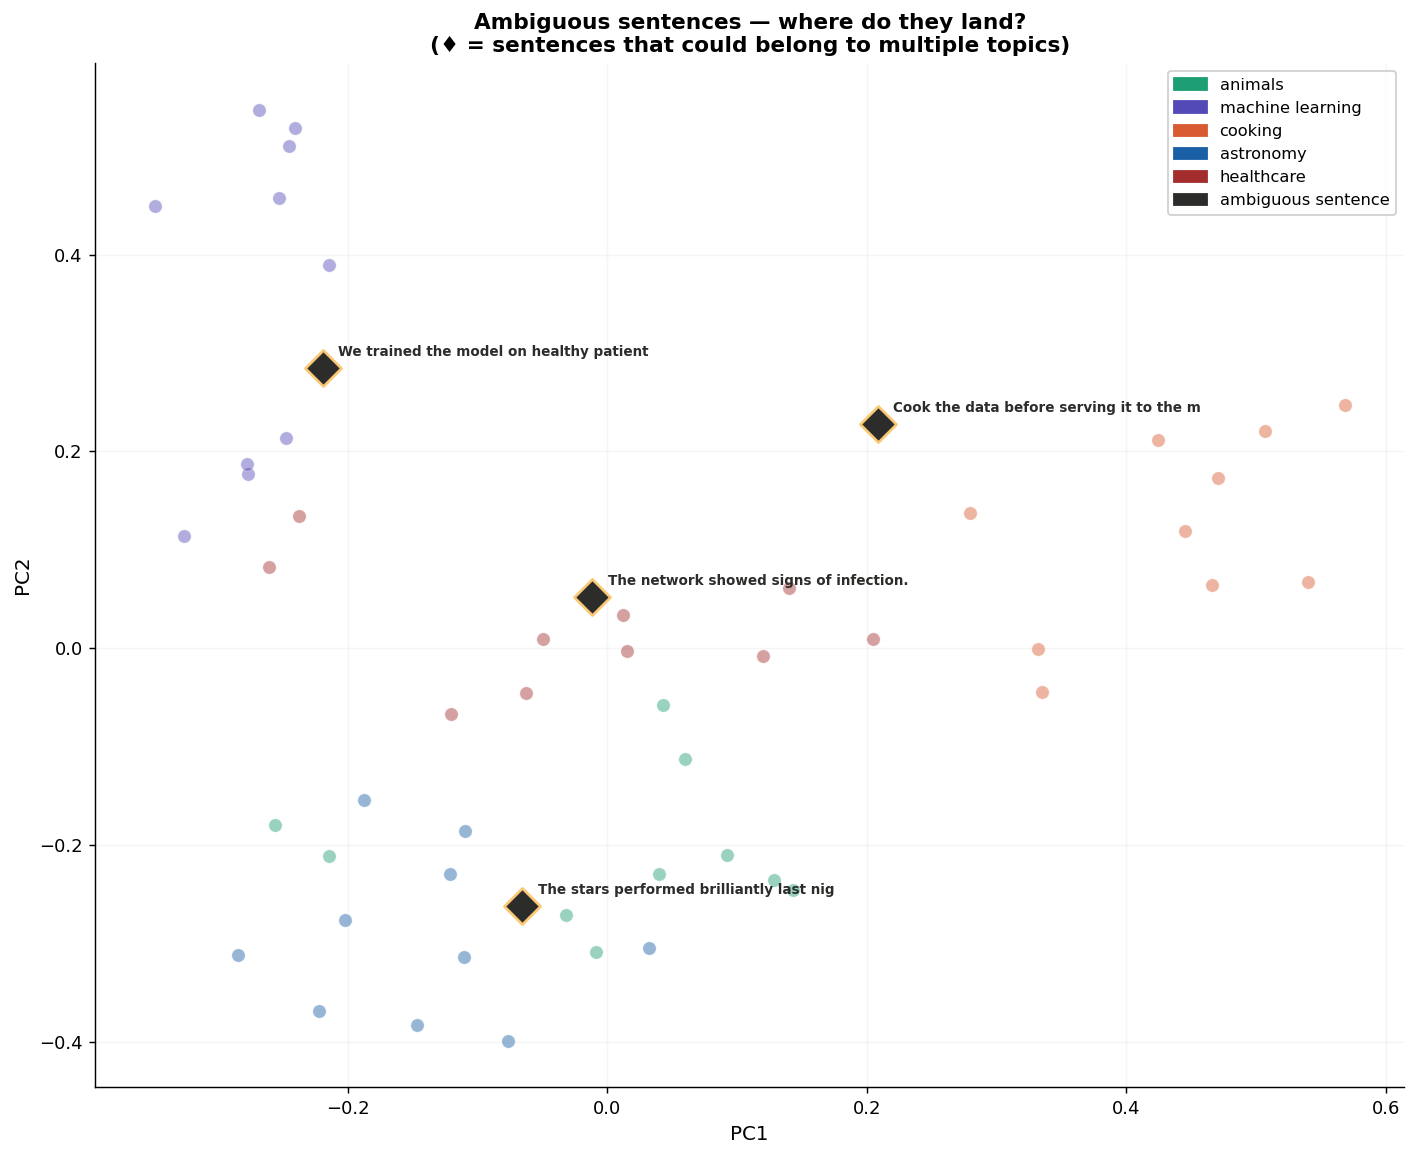

Saved: stage2_06_ambiguous.png

Observations:
  - Do the ambiguous sentences land near the cluster boundary?
  - Or do they land firmly in one cluster despite being ambiguous?
  - This tells you how the model resolves semantic ambiguity.


In [24]:
# Experiment B: plot ambiguous sentences on the cluster map
fig, ax = plt.subplots(figsize=(11, 9))

for topic in topic_list:
    mask = topic_labels_arr == topic
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=color_map[topic], s=55, alpha=0.45,
        edgecolors='white', linewidths=0.4, zorder=2
    )

# Ambiguous points
for i, (xy, sent) in enumerate(zip(amb_coords_2d, ambiguous)):
    ax.scatter(xy[0], xy[1], c='#2C2C2A', s=200, marker='D',
               zorder=5, edgecolors='#FAC775', linewidths=1.5)
    ax.text(xy[0] + 0.012, xy[1] + 0.012, sent[:40], fontsize=7.5,
            color='#2C2C2A', fontweight='bold', zorder=6)

legend_patches = [mpatches.Patch(color=color_map[t], label=t.replace('_', ' '))
                  for t in topic_list]
legend_patches.append(mpatches.Patch(color='#2C2C2A', label='ambiguous sentence'))
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.9)
ax.set_xlabel("PC1", fontsize=11); ax.set_ylabel("PC2", fontsize=11)
ax.set_title("Ambiguous sentences — where do they land?\n(♦ = sentences that could belong to multiple topics)",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.12, zorder=0)

plt.tight_layout()
plt.savefig('stage2_06_ambiguous.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage2_06_ambiguous.png")
print()
print("Observations:")
print("  - Do the ambiguous sentences land near the cluster boundary?")
print("  - Or do they land firmly in one cluster despite being ambiguous?")
print("  - This tells you how the model resolves semantic ambiguity.")

---
## 11. Challenge Tasks <a id='11'></a>

Complete these before Stage 3 (FAISS vector search).

In [ ]:
# Challenge 1 — Implement t-SNE and compare with PCA
#
# t-SNE is another dimensionality reduction technique.
# Unlike PCA (linear, preserves global variance),
# t-SNE is non-linear and preserves local neighborhood structure.
# It often produces tighter, more visually distinct clusters.
#
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, perplexity=15, random_state=42)
# coords_tsne = tsne.fit_transform(embeddings)
# ... plot side by side with PCA
#
# KEY QUESTION: Which gives cleaner cluster separation for this corpus?
# WHY DOES IT MATTER: t-SNE is not invertible — you cannot project a new
# query point into t-SNE space. PCA IS invertible. For a retrieval system
# where you need to project unseen queries, you MUST use PCA (or UMAP).

print("Challenge 1: implement t-SNE and compare visually with PCA")
print("Remember: t-SNE cannot project new points — only PCA can.")

In [ ]:
# Challenge 2 — Add your own domain (payer policy sentences)
#
# Add a 6th topic: insurance_policy
# Write 10 sentences about insurance coverage, prior auth, exclusions etc.
# Re-embed everything and plot.
#
# Questions to answer:
#   1. Does insurance_policy cluster near healthcare? How close?
#   2. Does it cluster near machine_learning at all? (it shouldn't)
#   3. What does this tell you about how your payer RAG system will behave
#      when a query about ML accidentally retrieves policy docs (or vice versa)?

insurance_sentences = [
    # Add 10 sentences here about insurance policies
    # e.g. "Prior authorization is required for MRI scans under Cigna."
]

print("Challenge 2: add insurance_policy topic and measure its cluster distance")
print("to healthcare vs all other topics")

In [ ]:
# Challenge 3 — PCA reconstruction error
#
# After projecting 384D -> 2D, reconstruct back to 384D using pca2.inverse_transform().
# Measure the cosine similarity between original and reconstructed embeddings.
# Plot a histogram of reconstruction errors.
#
# This tells you: how much does your 2D visualization distort the actual distances?
# If two points look close in 2D but have low cosine similarity after reconstruction,
# the 2D view is misleading you.
#
# reconstructed = pca2.inverse_transform(coords_2d)
# recon_sims = [cosine_similarity([embeddings[i]], [reconstructed[i]])[0][0]
#               for i in range(len(embeddings))]
# ... plot histogram

print("Challenge 3: measure PCA reconstruction fidelity per sentence")

In [ ]:
# Challenge 4 — Cluster purity metric
#
# For each point in the 2D plot, find its k nearest neighbors in 384D space.
# Count what fraction of those neighbors share the same topic label.
# This is called 'cluster purity at k'.
#
# Formula: purity(i, k) = count(same_topic neighbors in top-k) / k
#
# Compute purity@5 and purity@10 for every sentence.
# Plot: average purity per topic as a bar chart.
#
# WHY THIS MATTERS: purity@k is how you measure retrieval quality
# when you know the ground truth. It's the foundation of the eval
# harness you'll build in Stage 6.

print("Challenge 4: compute cluster purity@5 and purity@10 for each topic")
print("This metric connects Stage 2 (visualization) to Stage 6 (evaluation)")

---
## Summary

| What you built | Key insight |
|---|---|
| Manual PCA from eigendecomposition | PCA = find axes of maximum variance, project onto them |
| Verified PCA matches sklearn | Sign flips are normal; absolute distances match |
| 50-sentence 5-topic embedding | Same-topic sentences cluster in 384D geometric space |
| Scree plot + variance explained | 2D captures only ~X% — useful for intuition, not measurement |
| Model comparison (MiniLM vs MPNet) | More parameters = tighter clusters, but slower |
| Query vector in semantic space | RAG retrieval = find nearest neighbors to the query star |
| Ambiguous sentence experiment | Semantic ambiguity = landing near cluster boundaries |

## Saved plots
- `stage2_01_cluster_map.png` — basic 5-cluster visualization
- `stage2_02_annotated.png` — labeled with sentence text
- `stage2_03_variance_explained.png` — scree + cumulative variance
- `stage2_04_model_comparison.png` — MiniLM vs MPNet side by side
- `stage2_05_query_in_space.png` — query vectors with retrieval arrows
- `stage2_06_ambiguous.png` — where ambiguous sentences land

## Next: Stage 3 — FAISS vector search
Build a FAISS index, benchmark IndexFlatL2 vs IndexIVFFlat vs HNSW,  
and plot the recall vs speed tradeoff curve on a 10,000-doc corpus.